In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix
import numpy as np

In [19]:

df = pd.read_csv('hasil_sentimen.csv')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_content,tokens,tokens_no_stopwords,final_tokens,sentiment,sentiment_encoded
0,1ae2b4e0-0c90-4bbe-ac35-8f90f6e2ac1c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi macam apa iniiii,mau daftar aja susah...",1,211,4.12.0,2025-03-08 20:53:19,No reply,No reply,4.12.0,aplikasi macam apa iniiiimau daftar aja susah ...,"['aplikasi', 'macam', 'apa', 'iniiiimau', 'daf...","['aplikasi', 'iniiiimau', 'daftar', 'aja', 'su...","['aplikasi', 'iniiiimau', 'daftar', 'aja', 'su...",Negatif,0
1,5e08c4a6-d3f2-43ba-9a47-9332e1c545a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa eror terus jaringan nya??? Padahal wifi...,1,333,4.11.2,2025-02-25 07:10:13,Mohon maaf atas ketidaknyamanannya. Terkait ke...,2025-03-07 07:21:36,4.11.2,kenapa eror terus jaringan nya padahal wifi ja...,"['kenapa', 'eror', 'terus', 'jaringan', 'nya',...","['eror', 'jaringan', 'nya', 'wifi', 'jalan', '...","['eror', 'jaringan', 'nya', 'wifi', 'jalan', '...",Negatif,0
2,a07a2d9d-d058-4134-a356-607943185238,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk registrasi gagal terus, error setelah di...",1,207,4.12.0,2025-03-08 15:16:34,No reply,No reply,4.12.0,untuk registrasi gagal terus error setelah di ...,"['untuk', 'registrasi', 'gagal', 'terus', 'err...","['registrasi', 'gagal', 'error', 'refresh', 'u...","['registrasi', 'gagal', 'error', 'refresh', 'u...",Negatif,0
3,806384cb-43fb-4abd-9395-b7e0789153d1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong untuk verifikasi waktu mau daftar akun ...,1,287,4.11.2,2025-02-21 13:00:17,Mohon maaf atas ketidaknyamanannya. Pastikan j...,2025-03-11 04:30:26,4.11.2,tolong untuk verifikasi waktu mau daftar akun ...,"['tolong', 'untuk', 'verifikasi', 'waktu', 'ma...","['tolong', 'verifikasi', 'daftar', 'akun', 'di...","['tolong', 'verifikasi', 'daftar', 'akun', 'di...",Negatif,0
4,c61fd4a7-b571-452f-9260-7633c9a51006,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,1. Daftar kontrol deket2 hari gabisa karena er...,1,41,4.11.2,2025-03-07 03:48:53,No reply,No reply,4.11.2,daftar kontrol deket hari gabisa karena error...,"['daftar', 'kontrol', 'deket', 'hari', 'gabisa...","['daftar', 'kontrol', 'deket', 'gabisa', 'erro...","['daftar', 'kontrol', 'deket', 'gabisa', 'erro...",Negatif,0


In [20]:
# Pisahkan fitur dan target
X = df['cleaned_content']  # Fitur: teks
y = df['sentiment']  # Target: kategori sentimen

# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Membuat pipeline dengan CountVectorizer dan Naive Bayes
model = make_pipeline(CountVectorizer(), MultinomialNB())

# Melatih model
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Menampilkan hasil klasifikasi dan evaluasi model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Fungsi untuk prediksi sentimen baru
def predict_sentiment(text):
    return model.predict([text])[0]

# Contoh prediksi untuk review baru
new_review = "Aplikasi tidak bisa diakses, sangat mengecewakan."
predicted_sentiment = predict_sentiment(new_review)
print(f"Prediksi Sentimen: {predicted_sentiment}")

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.84      0.96      0.90     16285
      Netral       0.14      0.00      0.01      1626
     Positif       0.89      0.80      0.84      7739

    accuracy                           0.85     25650
   macro avg       0.62      0.59      0.58     25650
weighted avg       0.81      0.85      0.83     25650

Prediksi Sentimen: Negatif


# VISUALISASI

<ipython-input-26-0d1f1e140718>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


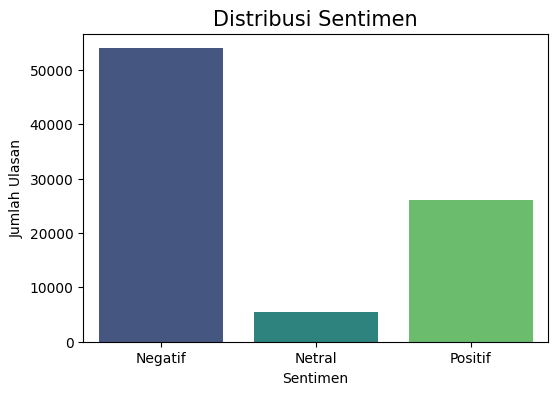

In [26]:

# 1. Visualisasi Distribusi Sentimen
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="viridis")
plt.title('Distribusi Sentimen', fontsize=15)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()



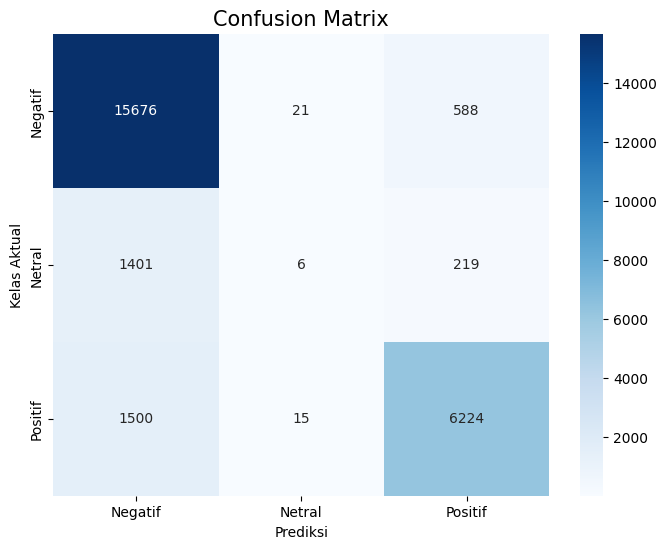

In [28]:
# 3. Confusion Matrix untuk Evaluasi Model
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix', fontsize=15)
plt.xlabel('Prediksi')
plt.ylabel('Kelas Aktual')
plt.show()


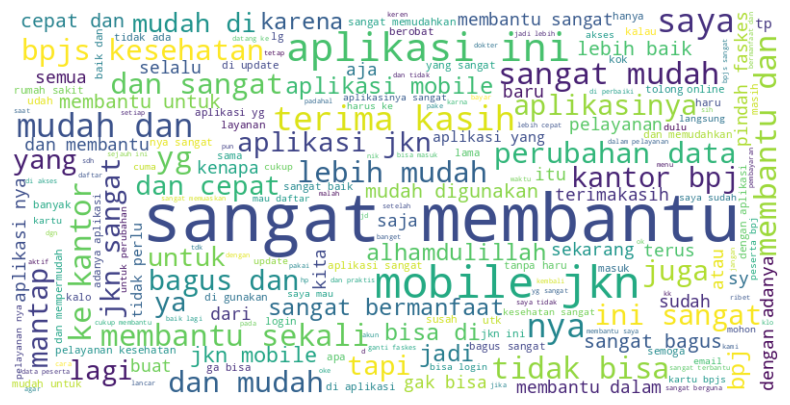

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengambil data review dengan sentimen tertentu, misalnya "Negatif"
negative_reviews = df[df['sentiment'] == 'Negatif']['cleaned_content']

# Gabungkan semua review menjadi satu teks
all_negative_reviews = ' '.join(negative_reviews)

# Membuat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_negative_reviews)

# Menampilkan WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


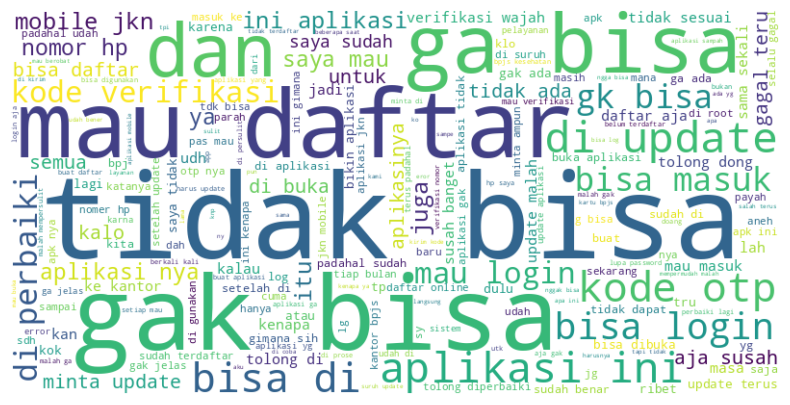

In [23]:
wfrom wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengambil data review dengan sentimen tertentu, misalnya "Negatif"
negative_reviews = df[df['sentiment'] == 'Negatif']['cleaned_content']

# Gabungkan semua review menjadi satu teks
all_negative_reviews = ' '.join(negative_reviews)

# Membuat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_negative_reviews)

# Menampilkan WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


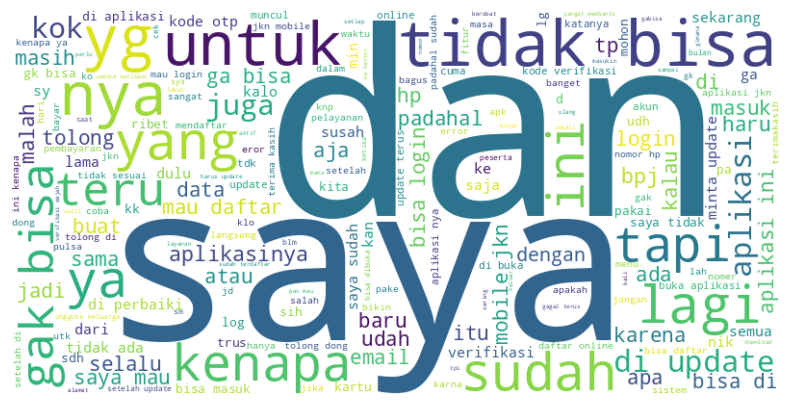

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengambil data review dengan sentimen tertentu, misalnya "Negatif"
negative_reviews = df[df['sentiment'] == 'Netral']['cleaned_content']

# Gabungkan semua review menjadi satu teks
all_negative_reviews = ' '.join(negative_reviews)

# Membuat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_negative_reviews)

# Menampilkan WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

